In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy import signal
from scipy.integrate import odeint

# Configurar matplotlib para gráficos bonitos
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


PROBLEMA 1 - Análise de sinal

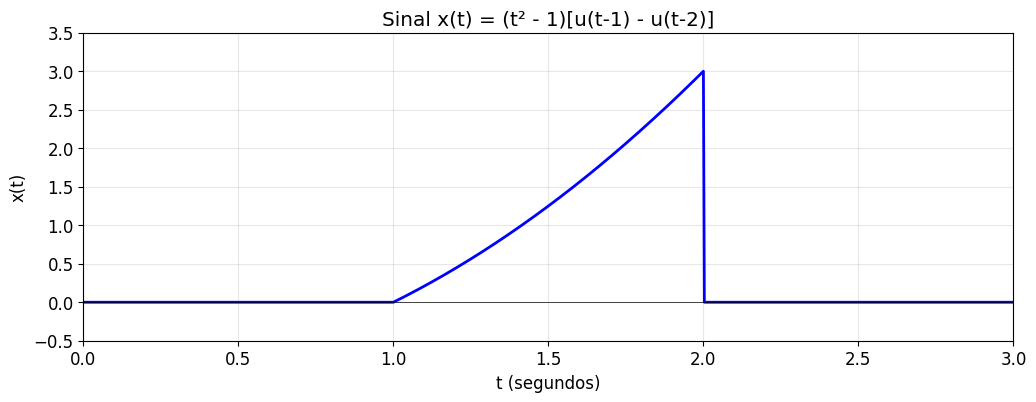

In [2]:
# Problema 1a: Plotar x(t)
t = np.linspace(0, 3, 1000)

# Criar x(t) = (t^2 - 1) no intervalo [1,2]
x1 = np.where((t >= 1) & (t <= 2), t**2 - 1, 0)

plt.figure(figsize=(12, 4))
plt.plot(t, x1, 'b-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title('Sinal x(t) = (t² - 1)[u(t-1) - u(t-2)]')
plt.xlabel('t (segundos)')
plt.ylabel('x(t)')
plt.xlim(0, 3)
plt.ylim(-0.5, 3.5)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.show()

In [3]:
# Problema 1b: Energia analítica
t_sym = sp.Symbol('t', real=True)
x_sym = t_sym**2 - 1
energia_analitica = sp.integrate(x_sym**2, (t_sym, 1, 2))
print(f"Energia analítica: {energia_analitica}")
print(f"Valor numérico: {float(energia_analitica):.6f} Joules")

Energia analítica: 38/15
Valor numérico: 2.533333 Joules


In [4]:
# Problema 1c: Energia numérica
dt = t[1] - t[0]
energia_numerica = np.sum(x1**2) * dt
print(f"Energia numérica: {energia_numerica:.6f} Joules")
print(f"Erro relativo: {abs(energia_numerica - float(energia_analitica))/float(energia_analitica)*100:.4f}%")

Energia numérica: 2.546865 Joules
Erro relativo: 0.5341%


PROBLEMA 2 - Sinal da Figura 1 (usando sinal triangular)

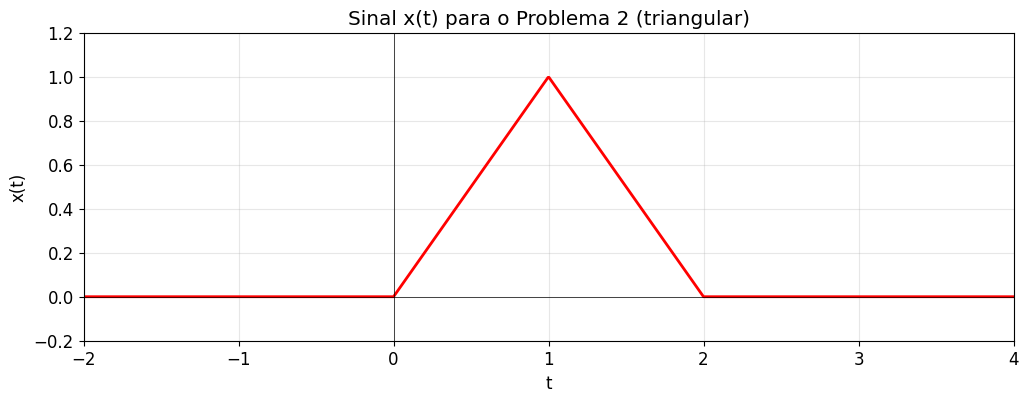

In [5]:
# Problema 2a e 2b: Definir e plotar x(t)
def sinal_original(t):
    """Sinal triangular: cresce de 0 a 1 em t=0 até t=1, decresce até t=2"""
    t = np.array(t)
    resultado = np.zeros_like(t)

    # Para t entre 0 e 1: t
    mask1 = (t >= 0) & (t < 1)
    resultado[mask1] = t[mask1]

    # Para t entre 1 e 2: 2-t
    mask2 = (t >= 1) & (t <= 2)
    resultado[mask2] = 2 - t[mask2]

    return resultado

t2 = np.linspace(-2, 4, 1000)
x2 = sinal_original(t2)

plt.figure(figsize=(12, 4))
plt.plot(t2, x2, 'r-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title('Sinal x(t) para o Problema 2 (triangular)')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.xlim(-2, 4)
plt.ylim(-0.2, 1.2)
plt.show()

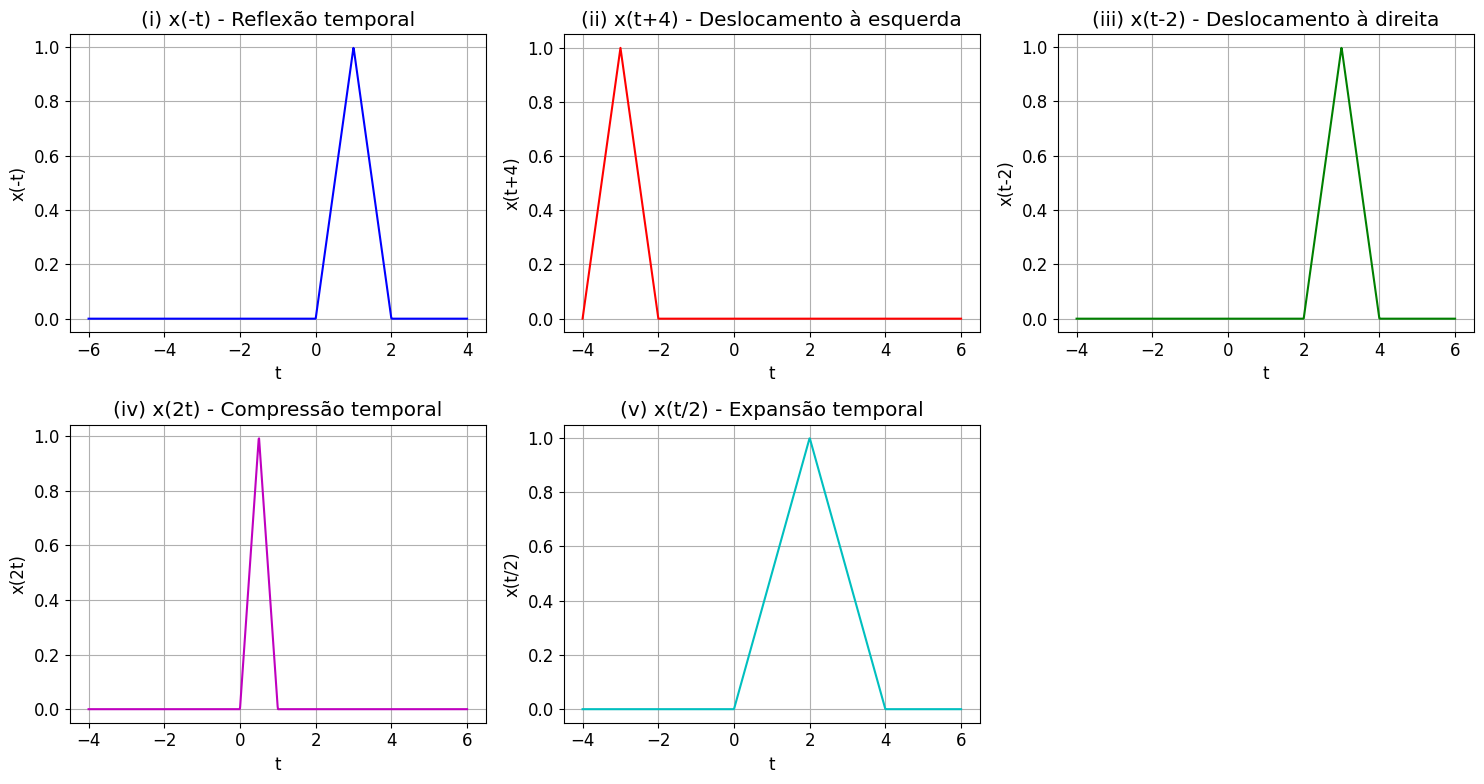


Explicações das operações:
(i) x(-t): Reflexão em torno do eixo vertical (inversão temporal)
(ii) x(t+4): Deslocamento para esquerda (antecipação de 4 unidades)
(iii) x(t-2): Deslocamento para direita (atraso de 2 unidades)
(iv) x(2t): Compressão temporal (sinal fica 2x mais rápido)
(v) x(t/2): Expansão temporal (sinal fica 2x mais lento)


In [6]:
# Problema 2c: Plotar sinais transformados
def plota_sinal(t, sinal_func, titulo, cor='b'):
    plt.plot(t, sinal_func, cor, linewidth=2)
    plt.grid(True, alpha=0.3)
    plt.title(titulo)
    plt.xlabel('t')
    plt.ylabel('x(t)')
    plt.axhline(y=0, color='k', linewidth=0.5)
    plt.axvline(x=0, color='k', linewidth=0.5)
    plt.xlim(-4, 6)
    plt.ylim(-0.2, 1.2)

# Criar figura com subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
t_plot = np.linspace(-4, 6, 1000)

# (i) x(-t)
axes[0,0].plot(-t_plot, sinal_original(-t_plot), 'b-')
axes[0,0].grid(True); axes[0,0].set_title('(i) x(-t) - Reflexão temporal')
axes[0,0].set_xlabel('t'); axes[0,0].set_ylabel('x(-t)')

# (ii) x(t+4)
axes[0,1].plot(t_plot, sinal_original(t_plot+4), 'r-')
axes[0,1].grid(True); axes[0,1].set_title('(ii) x(t+4) - Deslocamento à esquerda')
axes[0,1].set_xlabel('t'); axes[0,1].set_ylabel('x(t+4)')

# (iii) x(t-2)
axes[0,2].plot(t_plot, sinal_original(t_plot-2), 'g-')
axes[0,2].grid(True); axes[0,2].set_title('(iii) x(t-2) - Deslocamento à direita')
axes[0,2].set_xlabel('t'); axes[0,2].set_ylabel('x(t-2)')

# (iv) x(2t)
axes[1,0].plot(t_plot, sinal_original(2*t_plot), 'm-')
axes[1,0].grid(True); axes[1,0].set_title('(iv) x(2t) - Compressão temporal')
axes[1,0].set_xlabel('t'); axes[1,0].set_ylabel('x(2t)')

# (v) x(t/2)
axes[1,1].plot(t_plot, sinal_original(t_plot/2), 'c-')
axes[1,1].grid(True); axes[1,1].set_title('(v) x(t/2) - Expansão temporal')
axes[1,1].set_xlabel('t'); axes[1,1].set_ylabel('x(t/2)')

# Remover o sexto subplot vazio
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

# Explicações
print("\nExplicações das operações:")
print("(i) x(-t): Reflexão em torno do eixo vertical (inversão temporal)")
print("(ii) x(t+4): Deslocamento para esquerda (antecipação de 4 unidades)")
print("(iii) x(t-2): Deslocamento para direita (atraso de 2 unidades)")
print("(iv) x(2t): Compressão temporal (sinal fica 2x mais rápido)")
print("(v) x(t/2): Expansão temporal (sinal fica 2x mais lento)")

PROBLEMA 3 - Modulador AM

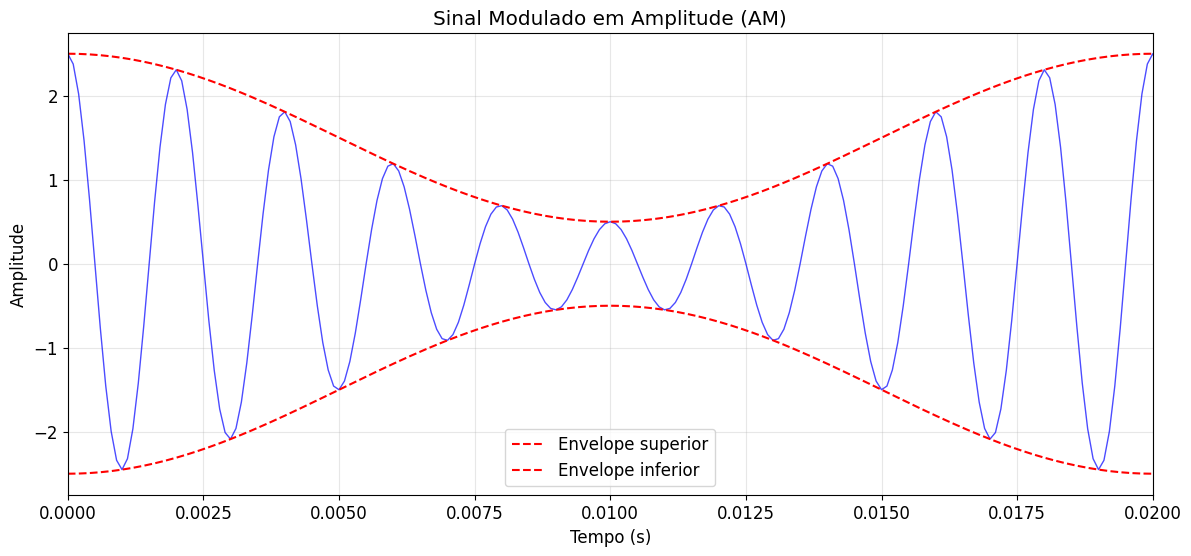

Frequência modulante: 50 Hz
Frequência portadora: 500 Hz
Índice de modulação: m = 0.67


In [7]:
# Problema 3: Gerar e plotar sinal AM
# Parâmetros
fm = 50    # Hz - frequência do modulante
fc = 500   # Hz - frequência da portadora
A = 1.5    # amplitude da portadora
fs = 10000 # Hz - frequência de amostragem (10kHz)

# Tempo de 0 a 0.1 segundos
t = np.linspace(0, 0.1, int(fs * 0.1) + 1)

# Sinal modulante
x_am = np.cos(2 * np.pi * fm * t)

# Sinal AM
y_am = (A + x_am) * np.cos(2 * np.pi * fc * t)

# Plotar
plt.figure(figsize=(14, 6))
plt.plot(t, y_am, 'b-', linewidth=1, alpha=0.7)
plt.plot(t, A + x_am, 'r--', linewidth=1.5, label='Envelope superior')
plt.plot(t, -(A + x_am), 'r--', linewidth=1.5, label='Envelope inferior')
plt.grid(True, alpha=0.3)
plt.title('Sinal Modulado em Amplitude (AM)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.xlim(0, 0.02)  # Zoom para ver melhor
plt.show()

print(f"Frequência modulante: {fm} Hz")
print(f"Frequência portadora: {fc} Hz")
print(f"Índice de modulação: m = {1/A:.2f}")

PROBLEMA 4 - Sistema LTI

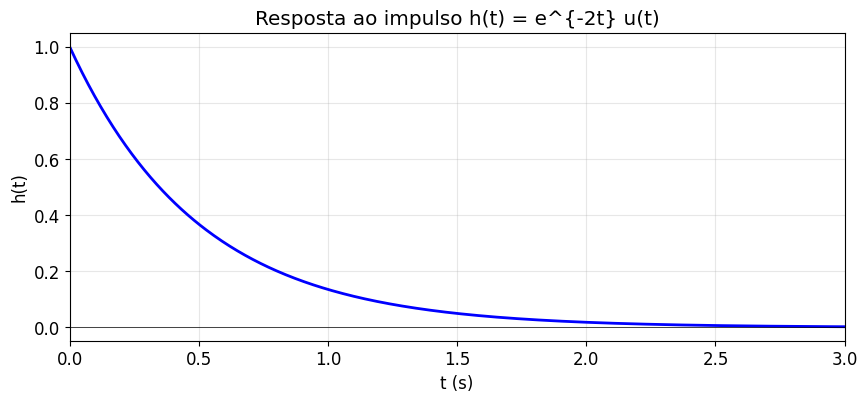

In [8]:
# Problema 4a: Plotar h(t)
t4 = np.linspace(0, 3, 500)
h1 = np.exp(-2 * t4)  # h(t) = e^{-2t} para t>=0

plt.figure(figsize=(10, 4))
plt.plot(t4, h1, 'b-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title('Resposta ao impulso h(t) = e^{-2t} u(t)')
plt.xlabel('t (s)')
plt.ylabel('h(t)')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.xlim(0, 3)
plt.show()

In [9]:
# Problema 4b: Análise de estabilidade e causalidade
from sympy import exp, integrate, oo

t_sym = sp.Symbol('t', real=True, positive=True)
h_sym = sp.exp(-2 * t_sym)

# Integral para estabilidade
integral_estabilidade = sp.integrate(h_sym, (t_sym, 0, sp.oo))

print("Análise do sistema com h(t) = e^{-2t} u(t):")
print("=" * 50)
print(f"Causalidade: h(t) = 0 para t < 0 => SISTEMA CAUSAL")
print(f"Estabilidade: ∫|h(t)|dt de 0 a ∞ = {integral_estabilidade} < ∞")
print(f"Portanto: SISTEMA ESTÁVEL")

Análise do sistema com h(t) = e^{-2t} u(t):
Causalidade: h(t) = 0 para t < 0 => SISTEMA CAUSAL
Estabilidade: ∫|h(t)|dt de 0 a ∞ = 1/2 < ∞
Portanto: SISTEMA ESTÁVEL


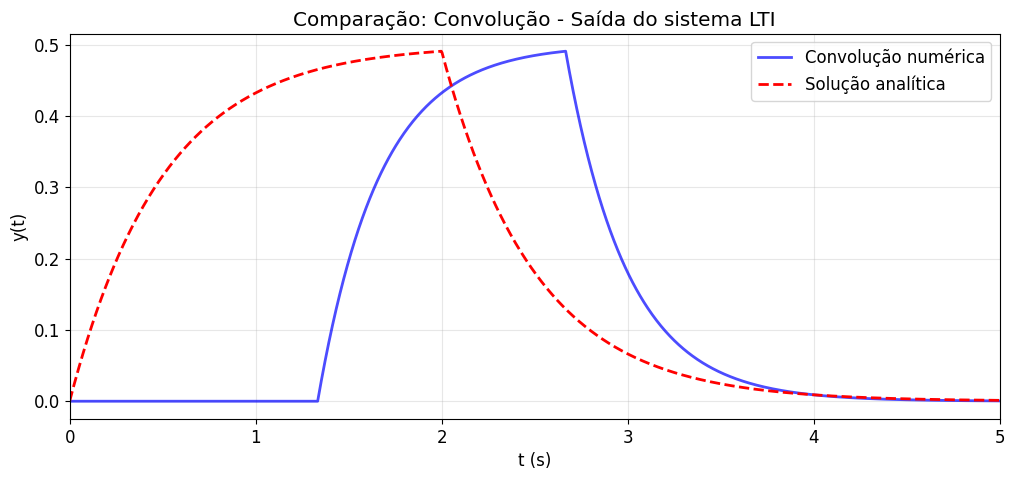

Erro máximo entre solução numérica e analítica: 0.465258


In [10]:
# Problemas 4c e 4d: Convolução
# Definir x(t) = u(t) - u(t-2) (pulso retangular de 0 a 2)
def x_pulso(t):
    t = np.array(t)
    return np.where((t >= 0) & (t <= 2), 1, 0)

# Criar vetor de tempo para convolução
t_conv = np.linspace(-1, 5, 1000)
dt_conv = t_conv[1] - t_conv[0]

# Sinal de entrada
x_p = x_pulso(t_conv)

# Resposta ao impulso
h_p = np.exp(-2 * t_conv) * (t_conv >= 0)

# Convolução numérica
y_num = np.convolve(x_p, h_p, mode='full') * dt_conv
t_y = np.linspace(0, 8, len(y_num))

# Solução analítica (calculada antes)
def y_analitico(t):
    t = np.array(t)
    y = np.zeros_like(t)
    mask1 = (t >= 0) & (t <= 2)
    mask2 = (t > 2)
    y[mask1] = (1 - np.exp(-2 * t[mask1])) / 2
    y[mask2] = (np.exp(-2 * (t[mask2] - 2)) - np.exp(-2 * t[mask2])) / 2
    return y

y_ana = y_analitico(t_y)

# Plotar comparação
plt.figure(figsize=(12, 5))
plt.plot(t_y, y_num, 'b-', label='Convolução numérica', linewidth=2, alpha=0.7)
plt.plot(t_y, y_ana, 'r--', label='Solução analítica', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title('Comparação: Convolução - Saída do sistema LTI')
plt.xlabel('t (s)')
plt.ylabel('y(t)')
plt.legend()
plt.xlim(0, 5)
plt.show()

# Erro máximo
erro_max = np.max(np.abs(y_num - y_ana))
print(f"Erro máximo entre solução numérica e analítica: {erro_max:.6f}")


Análise do sistema com h(t) = e^{t} u(t):
∫|h(t)|dt de 0 a ∞ = ∞ (diverge)
Portanto: SISTEMA INSTÁVEL
Causalidade: h(t) = 0 para t < 0 => SISTEMA CAUSAL


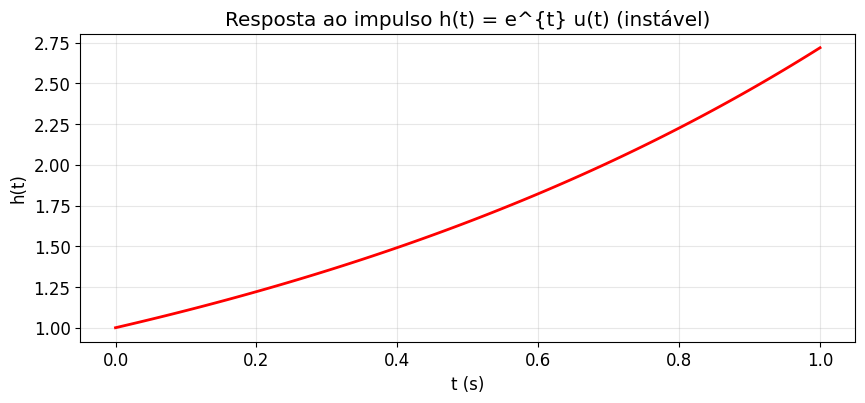

In [11]:
# Problema 4e: Sistema instável
print("\n" + "="*50)
print("Análise do sistema com h(t) = e^{t} u(t):")
print("="*50)

# Estabilidade
h2_sym = sp.exp(t_sym)
integral_instavel = sp.integrate(h2_sym, (t_sym, 0, 1))  # Só até 1, pois diverge
print(f"∫|h(t)|dt de 0 a ∞ = ∞ (diverge)")
print(f"Portanto: SISTEMA INSTÁVEL")
print(f"Causalidade: h(t) = 0 para t < 0 => SISTEMA CAUSAL")

# Plotar h(t) instável (limitando até t=1 para não explodir)
t_inst = np.linspace(0, 1, 100)
h_inst = np.exp(t_inst)

plt.figure(figsize=(10, 4))
plt.plot(t_inst, h_inst, 'r-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title('Resposta ao impulso h(t) = e^{t} u(t) (instável)')
plt.xlabel('t (s)')
plt.ylabel('h(t)')
plt.show()

PROBLEMA 5 - Circuito RLC (EDO de 2ª ordem)

In [12]:
# Problema 5a: Solução analítica (já calculada)
from sympy import symbols, exp, Function, Eq, dsolve, Derivative

print("="*60)
print("PROBLEMA 5 - Circuito RLC")
print("="*60)

# Definindo símbolos
t = sp.Symbol('t', real=True)
vo = sp.Function('vo')(t)
vi = 6 * sp.exp(-3*t)

# EDO: vo'' + 7vo' + 10vo = vi' + 6vi
edo = sp.Eq(Derivative(vo, t, t) + 7*Derivative(vo, t) + 10*vo,
            Derivative(vi, t) + 6*vi)

# Condições iniciais
cond_iniciais = {vo.subs(t, 0): 6, Derivative(vo, t).subs(t, 0): -4}

# Resolver
sol = sp.dsolve(edo, ics=cond_iniciais)

print("\nSolução analítica encontrada:")
print("="*50)
print(sp.simplify(sol))
print("="*50)

# Extrair expressão
vo_expr = sol.rhs
print(f"\nForma numérica: {vo_expr}")

PROBLEMA 5 - Circuito RLC

Solução analítica encontrada:
Eq(vo(t), (44*exp(3*t) - 27*exp(2*t) + 1)*exp(-5*t)/3)

Forma numérica: (44/3 - 9*exp(-t) + exp(-3*t)/3)*exp(-2*t)


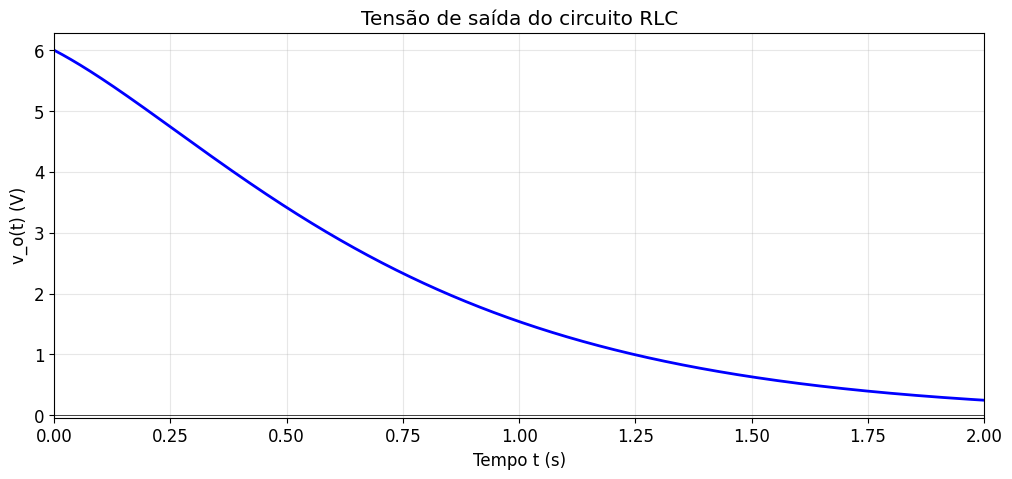

In [13]:
# Problema 5b: Plotar a saída
# Converter expressão simbólica para função numérica
vo_func = sp.lambdify(t, vo_expr, 'numpy')

t5 = np.linspace(0, 2, 1000)
vo_num = vo_func(t5)

plt.figure(figsize=(12, 5))
plt.plot(t5, vo_num, 'b-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title('Tensão de saída do circuito RLC')
plt.xlabel('Tempo t (s)')
plt.ylabel('v_o(t) (V)')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.xlim(0, 2)
plt.show()

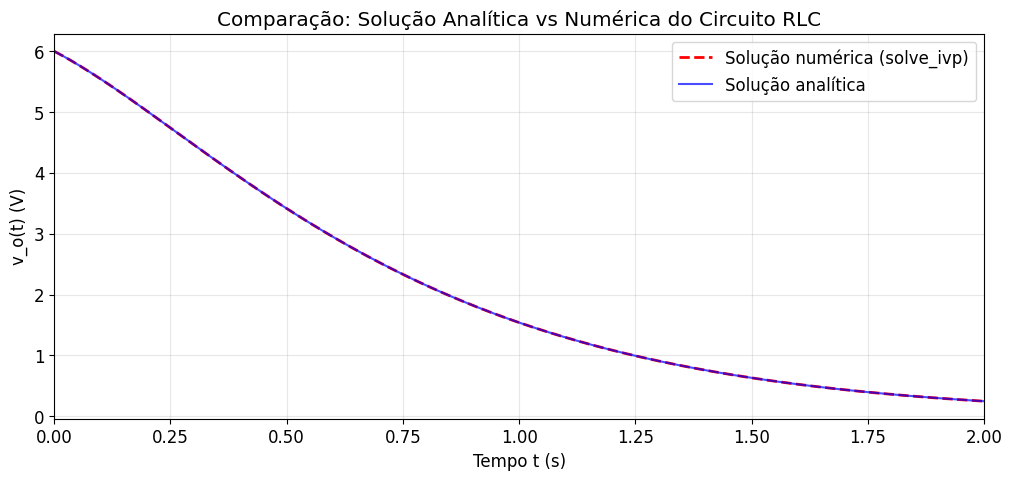

Erro máximo entre soluções: 6.20e-04 V


In [14]:
# Problema 5c: Verificação numérica com scipy

from scipy.integrate import solve_ivp

# Definir a EDO como sistema de 1ª ordem
# y0 = vo, y1 = vo'
def edo_sistema(t, y):
    vo, dvo = y
    vi = 6 * np.exp(-3*t)
    dvi = -18 * np.exp(-3*t)
    # vo'' = vi' + 6vi - 7vo' - 10vo
    d2vo = dvi + 6*vi - 7*dvo - 10*vo
    return [dvo, d2vo]

# Condições iniciais: vo(0)=6, vo'(0)=-4
y0 = [6, -4]
t_span = (0, 2)
t_eval = np.linspace(0, 2, 1000)

# Resolver numericamente
sol_num = solve_ivp(edo_sistema, t_span, y0, t_eval=t_eval, method='RK45')

# Plotar comparação
plt.figure(figsize=(12, 5))
plt.plot(t_eval, sol_num.y[0], 'r--', label='Solução numérica (solve_ivp)', linewidth=2)
plt.plot(t5, vo_num, 'b-', label='Solução analítica', linewidth=1.5, alpha=0.7)
plt.grid(True, alpha=0.3)
plt.title('Comparação: Solução Analítica vs Numérica do Circuito RLC')
plt.xlabel('Tempo t (s)')
plt.ylabel('v_o(t) (V)')
plt.legend()
plt.xlim(0, 2)
plt.show()

# Verificar diferença
erro_max = np.max(np.abs(sol_num.y[0] - vo_func(t_eval)))
print(f"Erro máximo entre soluções: {erro_max:.2e} V")